<a href="https://colab.research.google.com/github/wjsalswns11444-debug/blank-app/blob/main/%EC%88%98%EC%A0%95%EB%B3%B8_logD_GNN%EB%8B%A8%EB%8F%85%EA%B8%B0%EC%A4%80_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 기반 logD 예측 및 분자 구조 최적화 시스템

이 노트북은 연구계획서의 목표를 코드로 구현한 버전입니다.

## 연구 흐름

1. Lipophilicity 공개 데이터셋에서 SMILES와 실험 logD 값을 불러옵니다.
2. RDKit은 SMILES 변환, Morgan Fingerprint, Scaffold Split, 구조 그림에 필요한 최소 기능만 사용합니다.
3. 불필요한 RDKit descriptor 계산은 제거하고, Morgan Fingerprint 기반 Random Forest 모델을 학습합니다.
4. 분자를 그래프 구조로 바꾼 뒤 GNN 모델을 학습합니다.
5. Random Forest, GNN, RF-GNN 앙상블의 성능을 비교합니다.
6. Murcko Scaffold Split으로 새로운 분자 골격에 대한 예측 성능을 평가합니다.
7. 목표 logD 범위에서 벗어난 분자에 대해 작용기 변형 후보를 생성합니다.
8. 성능이 가장 좋은 GNN 단독 모델로 생성 후보 분자의 logD를 다시 예측하고, 목표 범위(1–3)에 들어오는 구조를 추천합니다.

## 포함된 핵심 시각화

1. Experimental logD 분포
2. GNN 학습 곡선
3. 모델 성능 비교 bar plot
4. 실제값 vs 예측값 parity plot
5. Model disagreement vs prediction error plot
6. 오차가 큰 분자 구조 grid
7. 구조 최적화 후보 분자 grid

## 주의

이 코드는 실제 합성 가능성까지 완전히 보장하는 retrosynthesis 모델은 아닙니다.  
연구계획서 수준에서는 “예측 기반 구조 변형 후보 추천 프로토타입”으로 쓰기에 적합합니다.


In [ ]:
# ============================================================
# Part 1. 라이브러리 설치 및 불러오기
# ============================================================

!pip -q install rdkit scikit-learn pandas numpy tensorflow

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
from IPython.display import display

import tensorflow as tf
from tensorflow.keras import layers, Model


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 52.4 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Part 2. 기본 설정
# ============================================================

DATA_PATH = "Lipophilicity.csv"   # 업로드한 데이터 파일 이름
SMILES_COL = "smiles"             # SMILES 열 이름
TARGET_COL = "exp"                # 실험 logD 값 열 이름

RANDOM_STATE = 42
TEST_SIZE = 0.2
VALID_SIZE = 0.1

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [ ]:
# ============================================================
# Part 3. 데이터 불러오기 및 전처리
# ============================================================

df = pd.read_csv(DATA_PATH)

work_df = df[[SMILES_COL, TARGET_COL]].copy()
work_df = work_df.dropna(subset=[SMILES_COL, TARGET_COL])
work_df = work_df.drop_duplicates()

work_df["mol"] = work_df[SMILES_COL].apply(Chem.MolFromSmiles)
work_df = work_df.dropna(subset=["mol"]).reset_index(drop=True)

work_df[TARGET_COL] = pd.to_numeric(work_df[TARGET_COL], errors="coerce")
work_df = work_df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print("정제 후 데이터 크기:", work_df.shape)
display(work_df.head())


정제 후 데이터 크기: (4200, 3)


,smiles,exp,mol
0,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14,3.54,<rdkit.Chem.rdchem.Mol object at 0x7ab9fbb64f90>
1,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...,-1.18,<rdkit.Chem.rdchem.Mol object at 0x7ab9fbb65070>
2,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl,3.69,<rdkit.Chem.rdchem.Mol object at 0x7ab9fbb650e0>
3,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...,3.37,<rdkit.Chem.rdchem.Mol object at 0x7ab9fbb65150>
4,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...,3.10,<rdkit.Chem.rdchem.Mol object at 0x7ab9fbb651c0>


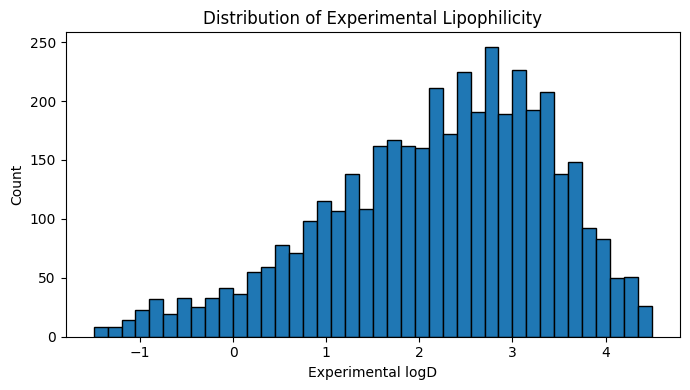

In [ ]:
# ============================================================
# Visualization 1. Experimental logD 분포
# ============================================================
# 예측 대상인 실험 logD 값이 어떤 범위에 분포하는지 확인합니다.

plt.figure(figsize=(7, 4))
plt.hist(work_df[TARGET_COL], bins=40, edgecolor="black")
plt.xlabel("Experimental logD")
plt.ylabel("Count")
plt.title("Distribution of Experimental Lipophilicity")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Part 4. Morgan fingerprint 생성
# ============================================================

# RDKit의 deprecated된 GetMorganFingerprintAsBitVect 대신
# MorganGenerator를 사용해서 경고가 뜨지 않도록 수정한 버전입니다.
_morgan_generator_cache = {}

def mol_to_morgan_fp(mol, radius=2, n_bits=2048):
    key = (radius, n_bits)
    if key not in _morgan_generator_cache:
        _morgan_generator_cache[key] = rdFingerprintGenerator.GetMorganGenerator(
            radius=radius, fpSize=n_bits
        )

    generator = _morgan_generator_cache[key]
    bit_vect = generator.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.int8)
    ConvertToNumpyArray(bit_vect, arr)
    return arr

X_fp = np.array([mol_to_morgan_fp(mol) for mol in work_df["mol"]])
y = work_df[TARGET_COL].values.astype(np.float32)

print("Morgan fingerprint shape:", X_fp.shape)


Morgan fingerprint shape: (4200, 2048)


### 참고
- 기존 `GetMorganFingerprintAsBitVect()`는 RDKit 최신 버전에서 deprecated warning이 발생할 수 있습니다.
- 이 노트북은 `rdFingerprintGenerator.GetMorganGenerator()` 방식으로 수정되어 경고 없이 Morgan fingerprint를 생성합니다.


In [ ]:
# ============================================================
# Part 5. Murcko Scaffold Split 함수
# ============================================================

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)


def scaffold_split_indices(smiles_list, test_size=0.2, random_state=42):
    """
    같은 scaffold를 가진 분자들이 train/test에 동시에 들어가지 않도록 분리합니다.
    실제 신약개발에서는 새로운 골격의 분자를 예측해야 하므로 더 엄격한 평가 방식입니다.
    """
    rng = np.random.default_rng(random_state)

    scaffold_to_indices = {}
    for idx, smiles in enumerate(smiles_list):
        scaffold = get_scaffold(smiles)
        scaffold_to_indices.setdefault(scaffold, []).append(idx)

    scaffold_groups = list(scaffold_to_indices.values())
    rng.shuffle(scaffold_groups)
    scaffold_groups = sorted(scaffold_groups, key=len, reverse=True)

    n_total = len(smiles_list)
    n_test_target = int(n_total * test_size)

    train_idx, test_idx = [], []
    for group in scaffold_groups:
        if len(test_idx) + len(group) <= n_test_target:
            test_idx.extend(group)
        else:
            train_idx.extend(group)

    return np.array(train_idx), np.array(test_idx)


all_indices = np.arange(len(work_df))

# 일반 random split: 참고용

# 실제 평가용 scaffold split
scaffold_train_idx, scaffold_test_idx = scaffold_split_indices(
    work_df[SMILES_COL].tolist(),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)



In [ ]:
# ============================================================
# Part 6. 평가 함수
# ============================================================
# Colab / scikit-learn 버전에 따라 mean_squared_error(squared=False)가 오류날 수 있어서
# RMSE를 직접 sqrt(MSE)로 계산하도록 수정했습니다.

def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


def train_rf_and_evaluate(train_idx, test_idx, split_name):
    X_train, X_test = X_fp[train_idx], X_fp[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    pred = rf_model.predict(X_test)

    metrics = evaluate_regression(y_test, pred)
    print(f"[{split_name}] RF 완료:", metrics)
    return rf_model, pred, metrics


In [ ]:
# ============================================================
# Part 7. Scaffold Split 기반 Random Forest 학습
# ============================================================
# 실제 신약 개발 상황에서는 학습 데이터와 다른 골격의 분자를 예측해야 하므로,
# Murcko scaffold split만 사용합니다.

rf_scaffold, rf_scaffold_pred, rf_scaffold_metrics = train_rf_and_evaluate(
    scaffold_train_idx, scaffold_test_idx, "Scaffold split"
)


[Scaffold split] RF 완료: {'MAE': 0.7183884202499774, 'RMSE': np.float64(0.9328441047143177), 'R2': 0.4539785094312202}


In [ ]:
# ============================================================
# Part 8. GNN 입력 데이터 생성
# ============================================================
# 분자를 원자 feature 행렬 X와 adjacency 행렬 A로 변환합니다.

ATOM_LIST = [1, 5, 6, 7, 8, 9, 15, 16, 17, 35, 53]  # H, B, C, N, O, F, P, S, Cl, Br, I
MAX_ATOMS = max(mol.GetNumAtoms() for mol in work_df["mol"])


def atom_features(atom):
    atomic_num = atom.GetAtomicNum()
    atom_type = [1 if atomic_num == n else 0 for n in ATOM_LIST]
    atom_type.append(1 if atomic_num not in ATOM_LIST else 0)  # 기타 원자

    degree = atom.GetDegree()
    degree_feat = [1 if degree == d else 0 for d in range(6)]

    return np.array(
        atom_type
        + degree_feat
        + [
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
            atom.GetTotalNumHs()
        ],
        dtype=np.float32
    )


N_ATOM_FEATURES = len(atom_features(work_df["mol"].iloc[0].GetAtomWithIdx(0)))


def mol_to_graph(mol, max_atoms=MAX_ATOMS):
    n_atoms = mol.GetNumAtoms()

    X = np.zeros((max_atoms, N_ATOM_FEATURES), dtype=np.float32)
    A = np.zeros((max_atoms, max_atoms), dtype=np.float32)

    for i, atom in enumerate(mol.GetAtoms()):
        X[i] = atom_features(atom)

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        A[i, j] = 1.0
        A[j, i] = 1.0

    # self-loop 추가
    for i in range(n_atoms):
        A[i, i] = 1.0

    # D^-1/2 A D^-1/2 normalization
    degree = A.sum(axis=1)
    degree[degree == 0] = 1.0
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt

    return X, A_norm.astype(np.float32)


graph_X = []
graph_A = []
for mol in work_df["mol"]:
    x_i, a_i = mol_to_graph(mol)
    graph_X.append(x_i)
    graph_A.append(a_i)

graph_X = np.array(graph_X, dtype=np.float32)
graph_A = np.array(graph_A, dtype=np.float32)

print("Graph atom feature shape:", graph_X.shape)
print("Graph adjacency shape:", graph_A.shape)


Graph atom feature shape: (4200, 115, 21)
Graph adjacency shape: (4200, 115, 115)


In [ ]:
# ============================================================
# Part 9. 간단한 GNN 모델 정의
# ============================================================

class GraphConv(layers.Layer):
    def __init__(self, units, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.dense = layers.Dense(units, activation=activation)

    def call(self, inputs):
        X, A = inputs
        H = tf.matmul(A, X)
        return self.dense(H)


class MaskedMeanPooling(layers.Layer):
    def call(self, inputs):
        H, X_input = inputs
        mask = tf.cast(tf.reduce_sum(tf.abs(X_input), axis=-1, keepdims=True) > 0, tf.float32)
        H = H * mask
        return tf.reduce_sum(H, axis=1) / (tf.reduce_sum(mask, axis=1) + 1e-8)


def build_gnn_model(max_atoms=MAX_ATOMS, n_features=N_ATOM_FEATURES):
    X_input = layers.Input(shape=(max_atoms, n_features), name="atom_features")
    A_input = layers.Input(shape=(max_atoms, max_atoms), name="adjacency")

    H = GraphConv(64)([X_input, A_input])
    H = GraphConv(64)([H, A_input])
    H = GraphConv(32)([H, A_input])
    H = MaskedMeanPooling()([H, X_input])

    H = layers.Dense(64, activation="relu")(H)
    H = layers.Dropout(0.2)(H)
    H = layers.Dense(32, activation="relu")(H)
    output = layers.Dense(1)(H)

    model = Model(inputs=[X_input, A_input], outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )
    return model


gnn_model = build_gnn_model()
gnn_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ atom_features       │ (None, 115, 21)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adjacency           │ (None, 115, 115)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_conv          │ (None, 115, 64)   │      1,408 │ atom_features[0]… │
│ (GraphConv)         │                   │            │ adjacency[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_conv_1        │ (None, 115, 64)   │      4,160 │ graph_conv[0][0], │
│ (GraphConv)         │                   │            │ adjacency[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_conv_2        │ (None, 115, 32)   │      2,080 │ graph_conv_1[0][… │
│ (GraphConv)         │                   │            │ adjacency[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean_pooling │ (None, 32)        │          0 │ graph_conv_2[0][… │
│ (MaskedMeanPooling) │                   │            │ atom_features[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      2,112 │ masked_mean_pool… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,873 (46.38 KB)

 Trainable params: 11,873 (46.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Part 10. GNN 학습
# ============================================================
# GNN도 RF와 같은 scaffold test set으로 평가합니다.
# train 내부에서만 validation set을 나눕니다.

gnn_train_idx, gnn_valid_idx = train_test_split(
    scaffold_train_idx,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE
)

Xg_train = graph_X[gnn_train_idx]
Ag_train = graph_A[gnn_train_idx]
yg_train = y[gnn_train_idx]

Xg_valid = graph_X[gnn_valid_idx]
Ag_valid = graph_A[gnn_valid_idx]
yg_valid = y[gnn_valid_idx]

Xg_test = graph_X[scaffold_test_idx]
Ag_test = graph_A[scaffold_test_idx]
y_test_scaffold = y[scaffold_test_idx]

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )
]

history = gnn_model.fit(
    [Xg_train, Ag_train],
    yg_train,
    validation_data=([Xg_valid, Ag_valid], yg_valid),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

gnn_scaffold_pred = gnn_model.predict([Xg_test, Ag_test]).ravel()
gnn_scaffold_metrics = evaluate_regression(y_test_scaffold, gnn_scaffold_pred)

print("[Scaffold split] GNN 완료:", gnn_scaffold_metrics)


Epoch 1/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 2.3240 - mae: 1.2266 - val_loss: 1.3664 - val_mae: 0.9747
Epoch 2/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.3840 - mae: 0.9501 - val_loss: 1.2898 - val_mae: 0.9479
Epoch 3/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.2833 - mae: 0.9189 - val_loss: 1.1734 - val_mae: 0.8879
Epoch 4/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.1802 - mae: 0.8767 - val_loss: 1.2426 - val_mae: 0.9097
Epoch 5/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.1367 - mae: 0.8548 - val_loss: 1.1645 - val_mae: 0.8809
Epoch 6/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 1.0594 - mae: 0.8276 - val_loss: 1.1328 - val_mae: 0.8695
Epoch 7/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.9699 - mae: 0.7910 - val_loss: 0.9866 - val_mae: 0.8037
Epoch 8/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.9301 - mae: 0.7764 - val_loss: 0.9240 - val_mae: 0.7725
Epoch 9/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - l

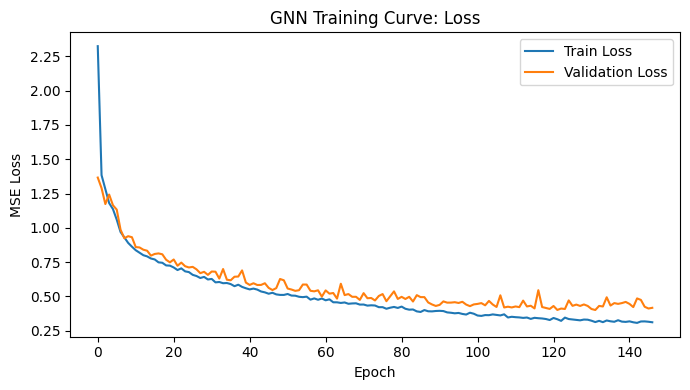

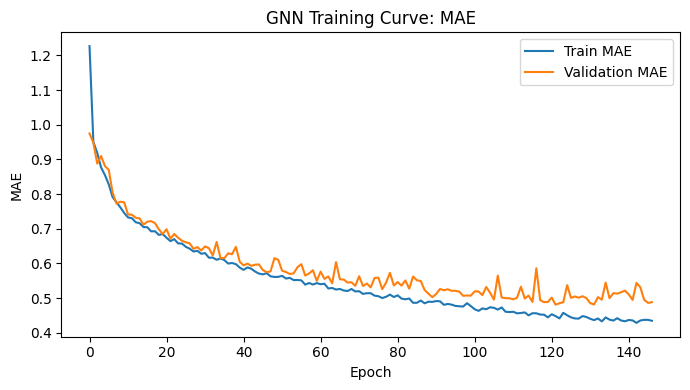

In [ ]:
# ============================================================
# Visualization 2. GNN 학습 곡선
# ============================================================
# train loss와 validation loss가 함께 감소하는지 확인하여 학습 안정성과 overfitting 여부를 봅니다.

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GNN Training Curve: Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("GNN Training Curve: MAE")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
ensemble_pred = (rf_scaffold_pred + gnn_scaffold_pred) / 2
ensemble_metrics = evaluate_regression(y_test_scaffold, ensemble_pred)
print(f"[Scaffold split] Ensemble 완료: {ensemble_metrics}")

metrics_df = pd.DataFrame({
    "RF Scaffold Split": rf_scaffold_metrics,
    "GNN Scaffold Split": gnn_scaffold_metrics,
    "Ensemble Scaffold Split": ensemble_metrics
}).T

display(metrics_df)

[Scaffold split] Ensemble 완료: {'MAE': 0.5491788064637917, 'RMSE': np.float64(0.7122389353961475), 'R2': 0.6816953258324574}


,MAE,RMSE,R2
RF Scaffold Split,0.718388,0.932844,0.453979
GNN Scaffold Split,0.516624,0.673585,0.715307
Ensemble Scaffold Split,0.549179,0.712239,0.681695


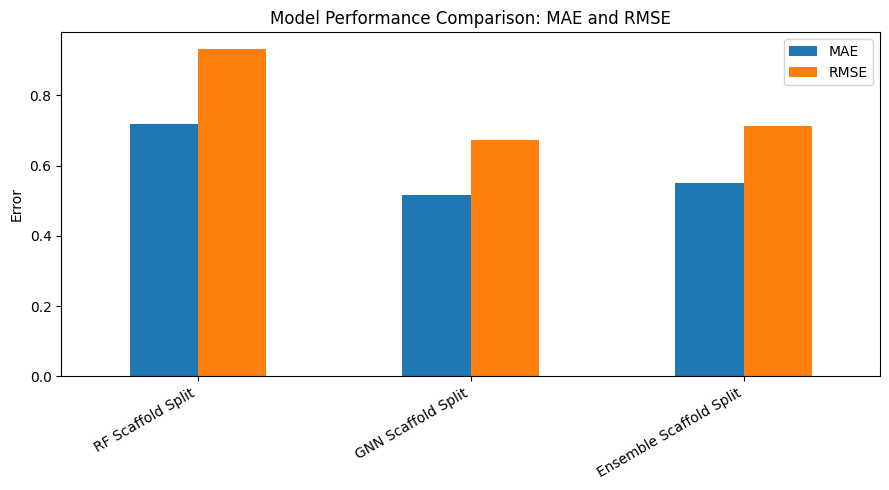

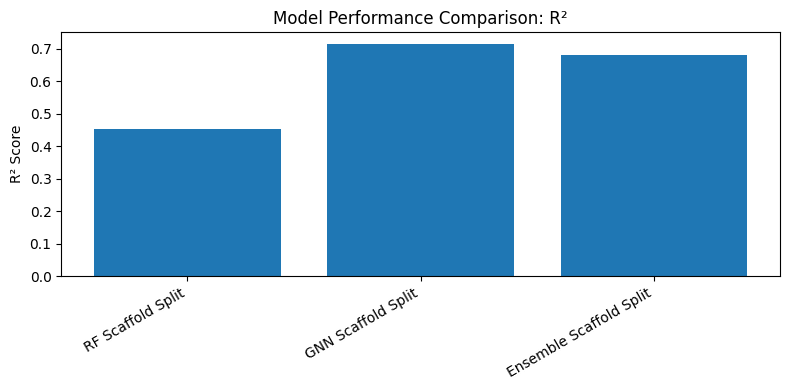

In [ ]:
# ============================================================
# Visualization 3. 모델 성능 비교 Bar Plot
# ============================================================
# MAE와 RMSE는 낮을수록 좋고, R²는 높을수록 좋습니다.

metrics_df[["MAE", "RMSE"]].plot(kind="bar", figsize=(9, 5))
plt.ylabel("Error")
plt.title("Model Performance Comparison: MAE and RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(metrics_df.index, metrics_df["R2"])
plt.ylabel("R² Score")
plt.title("Model Performance Comparison: R²")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

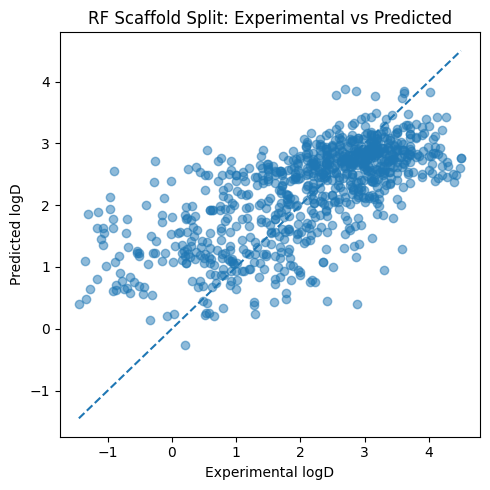

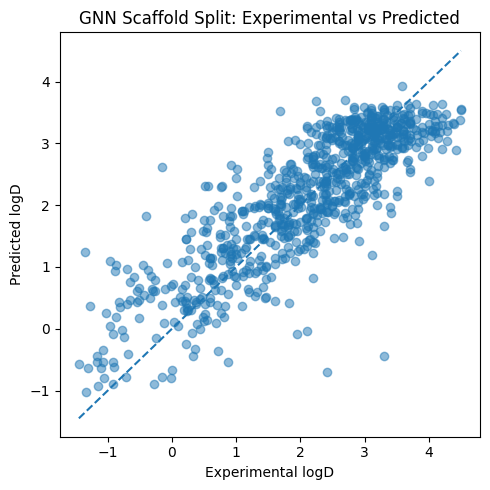

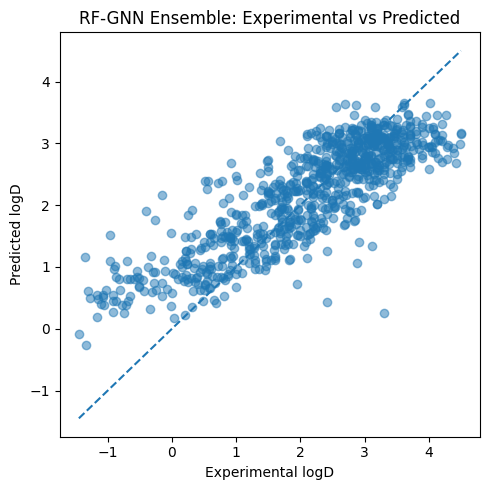

In [ ]:
# ============================================================
# Visualization 4. 실제값 vs 예측값 Parity Plot
# ============================================================
# 점들이 대각선에 가까울수록 예측이 정확합니다.

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.5)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Experimental logD")
    plt.ylabel("Predicted logD")
    plt.title(title)
    plt.tight_layout()
    plt.show()

parity_plot(y_test_scaffold, rf_scaffold_pred, "RF Scaffold Split: Experimental vs Predicted")
parity_plot(y_test_scaffold, gnn_scaffold_pred, "GNN Scaffold Split: Experimental vs Predicted")
parity_plot(y_test_scaffold, ensemble_pred, "RF-GNN Ensemble: Experimental vs Predicted")


In [ ]:
# ============================================================
# Part 12. 어떤 분자에서 못 맞추는지 확인
# ============================================================

def lipophilicity_comment(value):
    if value < 1:
        return "낮은 지용성"
    elif value <= 3:
        return "중간 지용성"
    elif value <= 5:
        return "높은 지용성"
    else:
        return "매우 높은 지용성"

# Calculate model disagreement
model_disagreement = np.abs(rf_scaffold_pred - gnn_scaffold_pred)

prediction_output = pd.DataFrame({
    "SMILES": work_df.loc[scaffold_test_idx, SMILES_COL].values,
    "Experimental_logD": y_test_scaffold,
    "RF_pred": rf_scaffold_pred,
    "GNN_pred": gnn_scaffold_pred,
    "Ensemble_pred": ensemble_pred,
    "Model_disagreement": model_disagreement,
})

prediction_output["Ensemble_abs_error"] = np.abs(
    prediction_output["Experimental_logD"] - prediction_output["Ensemble_pred"]
)
prediction_output["Lipophilicity_comment"] = prediction_output["Ensemble_pred"].apply(lipophilicity_comment)

print("오차가 큰 분자 TOP 20")
display(prediction_output.sort_values("Ensemble_abs_error", ascending=False).head(20))

print("모델 간 예측 차이가 큰 분자 TOP 20")
display(prediction_output.sort_values("Model_disagreement", ascending=False).head(20))

오차가 큰 분자 TOP 20


,SMILES,Experimental_logD,RF_pred,GNN_pred,Ensemble_pred,Model_disagreement,Ensemble_abs_error,Lipophilicity_comment
599,OC(=O)c1ccc2cccc(O)c2n1,3.30,0.952200,-0.434161,0.259020,1.386361,3.040980,낮은 지용성
17,OC(=O)c1ccccc1O,-1.36,1.091480,1.234827,1.163154,0.143347,2.523154,중간 지용성
71,Nc1ccccc1[N+](=O)[O-],-0.96,1.932565,1.088529,1.510547,0.844036,2.470547,중간 지용성
10,CC(N)C(=O)Nc1c(C)cccc1C,-0.15,1.722003,2.621082,2.171543,0.899078,2.321543,중간 지용성
76,CCS(=O)(=O)c1ccc(c(C)c1)c2cc(ccc2O[C@H](C)C(=O...,-0.40,1.996946,1.823201,1.910074,0.173745,2.310074,중간 지용성
685,CNS(=O)(=O)Cc1ccc2[nH]cc(CCN(C)C)c2c1,-0.96,2.129320,0.049207,1.089263,2.080113,2.049263,중간 지용성
69,CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(c1)C(=O)C,-0.27,2.721241,0.789039,1.755140,1.932202,2.025140,중간 지용성
43,CCOC(=O)c1ccc(OC(=O)CCCCCN=C(N)N)cc1,2.41,1.570785,-0.701017,0.434884,2.271802,1.975116,낮은 지용성
686,OC(=O)CSc1c[nH]c2ccccc12,-1.31,1.856897,-0.631750,0.612574,2.488646,1.922574,낮은 지용성
303,CNC(=O)c1cccc2c1c(Sc3ccc(Cl)cc3)c(C)n2CC(=O)O,-0.89,1.088210,0.926864,1.007537,0.161346,1.897537,중간 지용성


모델 간 예측 차이가 큰 분자 TOP 20


,SMILES,Experimental_logD,RF_pred,GNN_pred,Ensemble_pred,Model_disagreement,Ensemble_abs_error,Lipophilicity_comment
53,CC(=N)NCc1ccccc1,-0.28,2.376381,-0.889157,0.743612,3.265539,1.023612,낮은 지용성
52,CCN(CC)CCNC(=O)c1cc(ccc1OC)S(=O)(=O)C,-0.90,2.552764,-0.616336,0.968214,3.169100,1.868214,낮은 지용성
424,CNCC[C@@H](Oc1cc(OC)ccc1C#N)c2ccccc2,0.87,2.289387,-0.531905,0.878741,2.821292,0.008741,낮은 지용성
13,CN[C@@H](C)[C@H](O)c1ccccc1,-1.15,1.891027,-0.930066,0.480480,2.821093,1.630480,낮은 지용성
604,CCN(CC)CCCNCc1cc(Cl)c2cccnc2c1O,0.72,2.389133,-0.366089,1.011522,2.755223,0.291522,중간 지용성
12,CCN(CC)CCNC(=O)c1ccc(N)cc1,-0.92,1.776167,-0.886234,0.444966,2.662401,1.364966,낮은 지용성
64,Oc1cc(Cl)cc(Cl)c1,3.58,1.293460,3.932464,2.612962,2.639004,0.967038,중간 지용성
2,CC(C)C(=O)NCCNCC(O)COc1ccc(O)cc1,-0.15,1.843528,-0.786517,0.528506,2.630046,0.678506,낮은 지용성
8,CS(=O)(=O)c1ccc(cc1)[C@@H](O)[C@@H](CF)NC(=O)C...,0.44,2.539700,-0.003246,1.268227,2.542946,0.828227,중간 지용성
9,CCN(CC)CCOC(=O)c1ccc(N)cc1,0.00,1.816477,-0.674265,0.571106,2.490742,0.571106,낮은 지용성


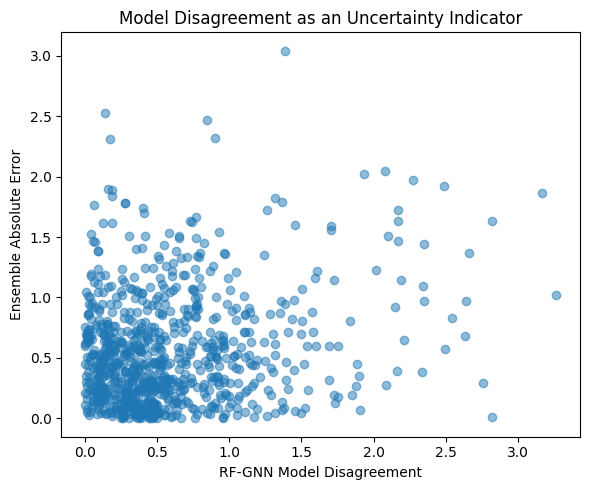

Model disagreement와 ensemble absolute error의 상관계수: 0.211


In [ ]:
# ============================================================
# Visualization 5. Model Disagreement vs Prediction Error
# ============================================================
# RF와 GNN 예측 차이가 클수록 실제 오차도 커지는지 확인합니다.

plt.figure(figsize=(6, 5))
plt.scatter(
    prediction_output["Model_disagreement"],
    prediction_output["Ensemble_abs_error"],
    alpha=0.5
)
plt.xlabel("RF-GNN Model Disagreement")
plt.ylabel("Ensemble Absolute Error")
plt.title("Model Disagreement as an Uncertainty Indicator")
plt.tight_layout()
plt.show()

corr = prediction_output["Model_disagreement"].corr(
    prediction_output["Ensemble_abs_error"]
)
print(f"Model disagreement와 ensemble absolute error의 상관계수: {corr:.3f}")


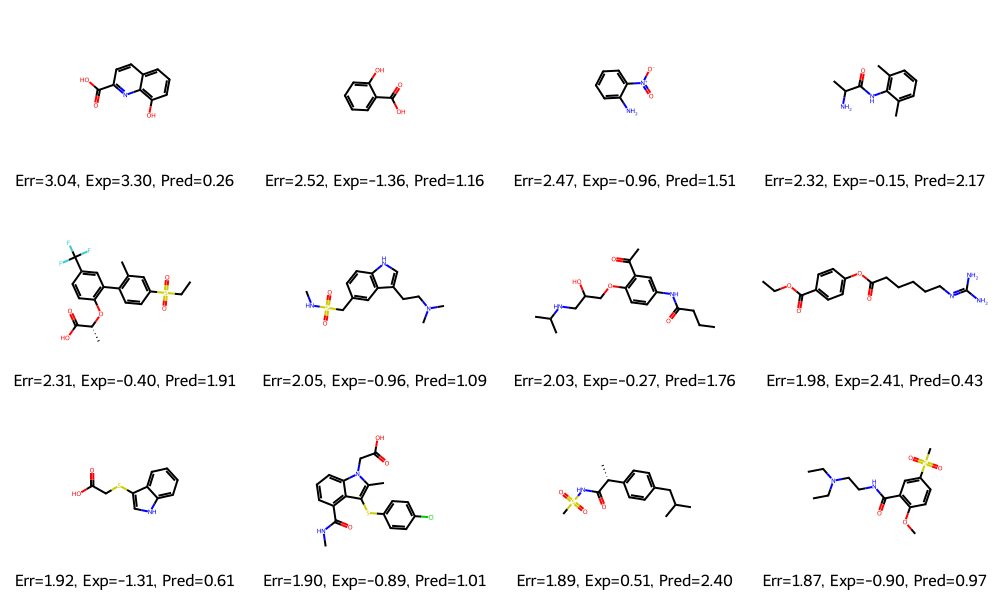

In [ ]:
# ============================================================
# Visualization 6. 오차가 큰 분자 구조 Grid
# ============================================================
# SMILES만 보는 것보다 어떤 구조에서 모델이 크게 틀렸는지 직관적으로 확인할 수 있습니다.

top_error = prediction_output.sort_values("Ensemble_abs_error", ascending=False).head(12)

mols = [Chem.MolFromSmiles(smi) for smi in top_error["SMILES"]]
legends = [
    f"Err={err:.2f}, Exp={exp:.2f}, Pred={pred:.2f}"
    for err, exp, pred in zip(
        top_error["Ensemble_abs_error"],
        top_error["Experimental_logD"],
        top_error["Ensemble_pred"]
    )
]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(250, 200),
    legends=legends
)

display(img)


In [ ]:
# ============================================================
# Part 13. 결과 저장
# ============================================================

metrics_df.to_csv("model_performance_RF_GNN_scaffold.csv")
prediction_output.to_csv("RF_GNN_ensemble_predictions.csv", index=False)

print("저장 완료:")
print("- model_performance_RF_GNN_scaffold.csv")
print("- RF_GNN_ensemble_predictions.csv")

저장 완료:
- model_performance_RF_GNN_scaffold.csv
- RF_GNN_ensemble_predictions.csv


# Part 14. 계획서 핵심 기능: 예측 기반 구조 최적화 시스템

앞부분까지는 “분자 구조 → logD 예측” 모델입니다.  
여기서는 연구계획서의 핵심 목표인 “예측 결과를 바탕으로 목표 logD 범위에 가까운 구조 변형 후보를 추천”하는 기능을 추가합니다.

구현 방식은 다음과 같습니다.

1. 입력 SMILES의 logD를 최종 선정 모델인 GNN 단독 모델로 예측합니다.
2. 예측 logD가 목표 범위보다 높으면 친수성 작용기 후보를 우선 적용합니다.
3. 예측 logD가 목표 범위보다 낮으면 소수성 작용기 후보를 우선 적용합니다.
4. RDKit reaction SMARTS를 이용해 변형 후보 분자를 생성합니다.
5. 생성된 후보를 다시 GNN 모델에 넣어 logD를 예측합니다.
6. 예측 logD가 목표 범위(1–3)에 들어온 후보를 추천합니다. 범위 안에서는 중심값에 가까운 정도를 추가 점수화하지 않습니다.


In [ ]:
# ============================================================
# Part 14-1. 새 SMILES에 대한 logD 예측 함수
# ============================================================

FINAL_PREDICTION_MODEL = "GNN"


def predict_logd_for_smiles(smiles, rf_model=rf_scaffold, gnn_model=gnn_model):
    """
    입력 SMILES 1개에 대해 RF, GNN, Ensemble logD를 모두 계산하되,
    최종 구조 추천에는 GNN 단독 예측값을 사용합니다.

    이유:
    - 모델 성능 비교에서 GNN 단독 모델이 가장 우수하다고 판단했기 때문입니다.
    - 따라서 후보 분자의 목표 범위(1~3) 판정도 GNN_pred 기준으로 수행합니다.

    반환값:
    - RF_pred: Morgan Fingerprint + Random Forest 예측값
    - GNN_pred: Graph Neural Network 예측값
    - Ensemble_pred: RF와 GNN 평균 예측값, 참고용
    - Selected_pred: 최종 추천에 실제로 사용하는 예측값, 즉 GNN_pred
    - Prediction_model: 최종 선택 모델 이름
    - Model_disagreement: RF와 GNN 예측 차이, 참고용
    """

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"유효하지 않은 SMILES입니다: {smiles}")

    # RF 예측: 최종 추천에는 쓰지 않고 비교/참고용으로만 계산합니다.
    fp = mol_to_morgan_fp(mol).reshape(1, -1)
    rf_pred = float(rf_model.predict(fp)[0])

    # GNN 예측: 최종 추천 기준입니다.
    if mol.GetNumAtoms() > MAX_ATOMS:
        # 현재 GNN은 학습 데이터의 최대 원자 수에 맞춰 padding되어 있으므로,
        # 그보다 큰 분자는 GNN 입력 크기와 맞지 않습니다.
        gnn_pred = np.nan
        ensemble_pred = np.nan
        selected_pred = np.nan
        disagreement = np.nan
    else:
        x_graph, a_graph = mol_to_graph(mol, max_atoms=MAX_ATOMS)
        gnn_pred = float(
            gnn_model.predict(
                [x_graph.reshape(1, MAX_ATOMS, N_ATOM_FEATURES),
                 a_graph.reshape(1, MAX_ATOMS, MAX_ATOMS)],
                verbose=0
            ).ravel()[0]
        )
        ensemble_pred = (rf_pred + gnn_pred) / 2
        selected_pred = gnn_pred
        disagreement = abs(rf_pred - gnn_pred)

    return {
        "SMILES": Chem.MolToSmiles(mol),
        "RF_pred": rf_pred,
        "GNN_pred": gnn_pred,
        "Ensemble_pred": ensemble_pred,
        "Selected_pred": selected_pred,
        "Prediction_model": FINAL_PREDICTION_MODEL,
        "Model_disagreement": disagreement
    }


# 예시:
# predict_logd_for_smiles("CCOc1ccc2nc(S(N)(=O)=O)sc2c1")


In [ ]:
# ============================================================
# Part 14-2. 작용기 변형 reaction library 정의
# ============================================================

from rdkit.Chem import AllChem

# 방향족 C-H 위치에 작용기를 도입하는 간단한 변형 규칙입니다.
# 실제 합성 가능성을 완전히 보장하지는 않지만, 구조-물성 최적화 후보를 생성하는 프로토타입으로 사용할 수 있습니다.
REACTION_LIBRARY = [
    {
        "name": "Aromatic hydroxylation",
        "group": "-OH",
        "direction": "decrease_logD",
        "expected_effect": "수소결합 donor/acceptor 증가, 극성 증가, logD 감소 가능",
        "reaction": AllChem.ReactionFromSmarts("[cH:1]>>[c:1]O")
    },
    {
        "name": "Aromatic amination",
        "group": "-NH2",
        "direction": "decrease_logD",
        "expected_effect": "극성 및 이온화 가능성 증가, logD 감소 가능",
        "reaction": AllChem.ReactionFromSmarts("[cH:1]>>[c:1]N")
    },
    {
        "name": "Aromatic carboxylation",
        "group": "-COOH",
        "direction": "decrease_logD",
        "expected_effect": "강한 극성/이온화 가능성 증가, logD 크게 감소 가능",
        "reaction": AllChem.ReactionFromSmarts("[cH:1]>>[c:1]C(=O)O")
    },
    {
        "name": "Aromatic fluorination",
        "group": "-F",
        "direction": "increase_or_tune_logD",
        "expected_effect": "소폭의 지용성 및 대사 안정성 변화 가능",
        "reaction": AllChem.ReactionFromSmarts("[cH:1]>>[c:1]F")
    },
    {
        "name": "Aromatic chlorination",
        "group": "-Cl",
        "direction": "increase_logD",
        "expected_effect": "소수성 증가, logD 증가 가능",
        "reaction": AllChem.ReactionFromSmarts("[cH:1]>>[c:1]Cl")
    },
    {
        "name": "Aromatic methylation",
        "group": "-CH3",
        "direction": "increase_logD",
        "expected_effect": "소수성 증가, logD 증가 가능",
        "reaction": AllChem.ReactionFromSmarts("[cH:1]>>[c:1]C")
    }
]


def sanitize_product_mol(mol):
    """
    RDKit reaction 결과물을 정리하고 유효한 분자인지 확인합니다.
    """
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
        return mol
    except Exception:
        return None


def basic_structure_filter(mol, max_heavy_atoms=80):
    """
    후보가 너무 커지는 경우만 제거합니다.
    불필요한 RDKit descriptor 계산을 줄이기 위해 분자량, TPSA, donor/acceptor 같은
    추가 물성 계산은 사용하지 않습니다.
    """
    if mol is None:
        return False
    if mol.GetNumHeavyAtoms() > max_heavy_atoms:
        return False
    return True


In [ ]:
# ============================================================
# Part 14-3. 구조 변형 후보 생성 함수
# ============================================================

def generate_modified_candidates(
    smiles,
    target_min=1.0,
    target_max=3.0,
    max_candidates_per_reaction=20
):
    """
    입력 분자의 방향족 C-H 위치에 여러 작용기를 도입하여 후보 분자를 생성합니다.

    target_min, target_max:
    - 목표 logD 범위입니다.
    - 최종 판정은 GNN 단독 예측값 기준으로 수행합니다.
    """

    input_mol = Chem.MolFromSmiles(smiles)
    if input_mol is None:
        raise ValueError(f"유효하지 않은 SMILES입니다: {smiles}")

    original_pred = predict_logd_for_smiles(smiles)
    original_logd = original_pred["Selected_pred"]

    if original_logd > target_max:
        preferred_direction = "decrease_logD"
    elif original_logd < target_min:
        preferred_direction = "increase_logD"
    else:
        preferred_direction = "tune_logD"

    rows = []
    seen = set()

    for rxn_info in REACTION_LIBRARY:
        rxn = rxn_info["reaction"]

        # 목표 범위 밖일 때는 필요한 방향의 변형에 우선순위를 둡니다.
        if preferred_direction == "decrease_logD":
            priority = 0 if rxn_info["direction"] == "decrease_logD" else 1
        elif preferred_direction == "increase_logD":
            priority = 0 if rxn_info["direction"] in ["increase_logD", "increase_or_tune_logD"] else 1
        else:
            priority = 0

        try:
            product_sets = rxn.RunReactants((input_mol,))
        except Exception:
            continue

        count = 0
        for product_tuple in product_sets:
            product_mol = product_tuple[0]
            product_mol = sanitize_product_mol(product_mol)
            if product_mol is None:
                continue
            if not basic_structure_filter(product_mol):
                continue

            product_smiles = Chem.MolToSmiles(product_mol, canonical=True)
            if product_smiles == Chem.MolToSmiles(input_mol, canonical=True):
                continue
            if product_smiles in seen:
                continue

            seen.add(product_smiles)
            rows.append({
                "Original_SMILES": Chem.MolToSmiles(input_mol, canonical=True),
                "Candidate_SMILES": product_smiles,
                "Modification": rxn_info["name"],
                "Introduced_group": rxn_info["group"],
                "Direction": rxn_info["direction"],
                "Expected_effect": rxn_info["expected_effect"],
                "Priority": priority
            })

            count += 1
            if count >= max_candidates_per_reaction:
                break

    candidate_df = pd.DataFrame(rows)
    if candidate_df.empty:
        print("생성된 후보가 없습니다. 방향족 C-H가 없는 분자일 수 있습니다.")
        return candidate_df, original_pred

    candidate_df = candidate_df.sort_values(["Priority", "Modification"]).reset_index(drop=True)
    return candidate_df, original_pred


# 예시:
# candidate_df, original_pred = generate_modified_candidates("CCOc1ccc2nc(S(N)(=O)=O)sc2c1")
# display(candidate_df.head())


In [ ]:
# ============================================================
# Part 14-4. 후보 분자 재예측 및 추천 함수
# ============================================================


def score_candidate_against_target(pred_logd, target_min, target_max):
    """
    GNN 예측 logD가 목표 범위에 들어오는지만 평가합니다.
    낮을수록 좋습니다.

    - 목표 범위 안에 있으면 0점입니다.
    - 목표 범위 밖이면 가장 가까운 경계값까지의 거리만큼 penalty가 커집니다.
    - 목표 범위 안에서는 중심값(예: 2.0)에 가까운지를 추가로 평가하지 않습니다.
    """

    if target_min <= pred_logd <= target_max:
        return 0
    elif pred_logd < target_min:
        return target_min - pred_logd
    else:
        return pred_logd - target_max


def recommend_logd_optimized_structures(
    smiles,
    target_min=1.0,
    target_max=3.0,
    top_n=10,
    max_candidates_per_reaction=20
):
    """
    전체 구조 최적화 pipeline입니다.

    입력:
    - smiles: 최적화하고 싶은 원본 분자
    - target_min, target_max: 목표 logD 범위
    - top_n: 추천할 후보 개수

    출력:
    - original_pred: 원본 분자의 예측 결과
    - recommendation_df: 추천 후보 표

    추천 기준:
    1. 최종 logD 판정에는 GNN_pred를 사용합니다.
    2. 예측 logD가 target_min ~ target_max 범위 안에 들어오면 목표 달성으로 봅니다.
    3. 범위 안 후보들끼리는 logD 중심값에 가까운 정도로 순위를 매기지 않습니다.
    4. 범위 안 후보가 있으면 그 후보들만 반환합니다.
    5. 범위 안 후보가 하나도 없을 때만, 범위 경계에 가장 가까운 후보를 참고용으로 반환합니다.
    """

    candidate_df, original_pred = generate_modified_candidates(
        smiles,
        target_min=target_min,
        target_max=target_max,
        max_candidates_per_reaction=max_candidates_per_reaction
    )

    if candidate_df.empty:
        return original_pred, candidate_df

    pred_rows = []
    for candidate_smiles in candidate_df["Candidate_SMILES"]:
        try:
            pred = predict_logd_for_smiles(candidate_smiles)
            pred_rows.append(pred)
        except Exception:
            pred_rows.append({
                "SMILES": candidate_smiles,
                "RF_pred": np.nan,
                "GNN_pred": np.nan,
                "Ensemble_pred": np.nan,
                "Selected_pred": np.nan,
                "Prediction_model": FINAL_PREDICTION_MODEL,
                "Model_disagreement": np.nan
            })

    pred_df = pd.DataFrame(pred_rows).rename(columns={"SMILES": "Candidate_SMILES"})

    recommendation_df = candidate_df.merge(pred_df, on="Candidate_SMILES", how="left")
    recommendation_df = recommendation_df.dropna(subset=["Selected_pred"]).copy()

    recommendation_df["Target_min"] = target_min
    recommendation_df["Target_max"] = target_max
    recommendation_df["In_target_range"] = recommendation_df["Selected_pred"].between(target_min, target_max)
    recommendation_df["Range_penalty"] = recommendation_df["Selected_pred"].apply(
        lambda x: score_candidate_against_target(x, target_min, target_max)
    )

    original_logd = original_pred["Selected_pred"]
    recommendation_df["Delta_logD_vs_original"] = recommendation_df["Selected_pred"] - original_logd

    # 목표는 GNN 예측 logD가 1~3 범위에 들어오는 것입니다.
    # 따라서 범위 안 후보는 모두 Range_penalty = 0으로 동점 처리하고,
    # 중심값(2.0)에 가까운 정도는 점수에 넣지 않습니다.
    # 표시 순서를 정하기 위한 보조 기준으로만 변형 우선순위를 사용합니다.
    recommendation_df["Final_score"] = (
        recommendation_df["Range_penalty"] * 10
        + recommendation_df["Priority"] * 0.5
    )

    in_range_df = recommendation_df[recommendation_df["In_target_range"]].copy()

    if not in_range_df.empty:
        # 범위 안에 들어온 후보가 있으면, 범위 안 후보만 반환합니다.
        # 이때 logD가 2.0에 가까운지는 고려하지 않습니다.
        result_df = in_range_df.sort_values(
            ["Priority", "Modification", "Candidate_SMILES"],
            ascending=[True, True, True]
        ).reset_index(drop=True)
    else:
        # 범위 안 후보가 없을 때만, 참고용으로 가장 가까운 후보를 보여줍니다.
        result_df = recommendation_df.sort_values(
            ["Range_penalty", "Priority", "Modification"],
            ascending=[True, True, True]
        ).reset_index(drop=True)

    return original_pred, result_df.head(top_n)


# 예시:
# original_pred, recommendation_df = recommend_logd_optimized_structures(
#     "CCOc1ccc2nc(S(N)(=O)=O)sc2c1",
#     target_min=1.0,
#     target_max=3.0,
#     top_n=10
# )
# print("원본 예측:", original_pred)
# display(recommendation_df)


In [ ]:
# ============================================================
# Part 14-5. 추천 결과 시각화 함수
# ============================================================

def visualize_recommendations(recommendation_df, original_smiles=None, max_mols=12):
    """
    추천 후보 분자의 구조를 grid로 시각화합니다.
    """

    if recommendation_df is None or recommendation_df.empty:
        print("시각화할 추천 후보가 없습니다.")
        return

    view_df = recommendation_df.head(max_mols).copy()
    mols = [Chem.MolFromSmiles(smi) for smi in view_df["Candidate_SMILES"]]

    legends = []
    for _, row in view_df.iterrows():
        legends.append(
            f"{row['Introduced_group']} | GNN={row['Selected_pred']:.2f} | Δ={row['Delta_logD_vs_original']:.2f}"
        )

    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(260, 220),
        legends=legends
    )
    display(img)


def explain_optimization_result(original_pred, recommendation_df):
    """
    추천 결과를 한국어로 간단히 해석합니다.
    """

    original_logd = original_pred["Selected_pred"]
    print(f"원본 분자의 GNN 예측 logD: {original_logd:.3f}")

    if recommendation_df.empty:
        print("추천 후보가 생성되지 않았습니다.")
        return

    best = recommendation_df.iloc[0]
    print("\n가장 추천되는 후보")
    print(f"- 변형: {best['Modification']} ({best['Introduced_group']})")
    print(f"- 후보 SMILES: {best['Candidate_SMILES']}")
    print(f"- GNN 예측 logD: {best['Selected_pred']:.3f}")
    print(f"- 원본 대비 logD 변화량: {best['Delta_logD_vs_original']:.3f}")
    print(f"- 목표 범위 포함 여부: {best['In_target_range']}")

    if original_logd > best["Target_max"]:
        print("\n해석: 원본의 logD가 목표보다 높기 때문에, 극성을 증가시키는 변형이 유리합니다.")
    elif original_logd < best["Target_min"]:
        print("\n해석: 원본의 logD가 목표보다 낮기 때문에, 소수성을 증가시키는 변형이 유리합니다.")
    else:
        print("\n해석: 원본이 이미 목표 범위 안에 있으므로, 과도한 구조 변경보다 미세 조정 후보를 보는 것이 좋습니다.")


입력 SMILES: CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1

원본 분자 예측 결과
{'SMILES': 'CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1', 'RF_pred': 1.5470493338058393, 'GNN_pred': 0.050139546394348145, 'Ensemble_pred': 0.7985944401000937, 'Selected_pred': 0.050139546394348145, 'Prediction_model': 'GNN', 'Model_disagreement': 1.4969097874114912}

추천 후보


,Original_SMILES,Candidate_SMILES,Modification,Introduced_group,Direction,Expected_effect,Priority,RF_pred,GNN_pred,Ensemble_pred,Selected_pred,Prediction_model,Model_disagreement,Target_min,Target_max,In_target_range,Range_penalty,Delta_logD_vs_original,Final_score
0,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1Cl,Aromatic chlorination,-Cl,increase_logD,"소수성 증가, logD 증가 가능",0,2.526628,0.837956,1.682292,0.837956,GNN,1.688673,1.0,3.0,False,0.162044,0.787816,1.620444
1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)c(Cl)c1,Aromatic chlorination,-Cl,increase_logD,"소수성 증가, logD 증가 가능",0,2.763870,0.832945,1.798408,0.832945,GNN,1.930926,1.0,3.0,False,0.167055,0.782805,1.670552
2,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,Cc1cc(COCCOC(C)C)ccc1OCC(O)CNC(C)C,Aromatic methylation,-CH3,increase_logD,"소수성 증가, logD 증가 가능",0,2.031714,0.350578,1.191146,0.350578,GNN,1.681136,1.0,3.0,False,0.649422,0.300439,6.494216
3,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,Cc1cc(OCC(O)CNC(C)C)ccc1COCCOC(C)C,Aromatic methylation,-CH3,increase_logD,"소수성 증가, logD 증가 가능",0,2.336795,0.337654,1.337225,0.337654,GNN,1.999141,1.0,3.0,False,0.662346,0.287514,6.623460
4,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)c(F)c1,Aromatic fluorination,-F,increase_or_tune_logD,소폭의 지용성 및 대사 안정성 변화 가능,0,2.308900,0.322256,1.315578,0.322256,GNN,1.986644,1.0,3.0,False,0.677744,0.272116,6.777442
5,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1F,Aromatic fluorination,-F,increase_or_tune_logD,소폭의 지용성 및 대사 안정성 변화 가능,0,1.915194,0.306406,1.110800,0.306406,GNN,1.608788,1.0,3.0,False,0.693594,0.256267,6.935935
6,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)c(O)c1,Aromatic hydroxylation,-OH,decrease_logD,"수소결합 donor/acceptor 증가, 극성 증가, logD 감소 가능",1,2.219290,-0.279105,0.970092,-0.279105,GNN,2.498395,1.0,3.0,False,1.279105,-0.329245,13.291053
7,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1O,Aromatic hydroxylation,-OH,decrease_logD,"수소결합 donor/acceptor 증가, 극성 증가, logD 감소 가능",1,1.843917,-0.364861,0.739528,-0.364861,GNN,2.208779,1.0,3.0,False,1.364861,-0.415001,14.148613
8,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1N,Aromatic amination,-NH2,decrease_logD,"극성 및 이온화 가능성 증가, logD 감소 가능",1,1.975605,-0.520968,0.727319,-0.520968,GNN,2.496573,1.0,3.0,False,1.520968,-0.571107,15.709678
9,CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1,CC(C)NCC(O)COc1ccc(COCCOC(C)C)c(N)c1,Aromatic amination,-NH2,decrease_logD,"극성 및 이온화 가능성 증가, logD 감소 가능",1,2.133420,-0.595400,0.769010,-0.595400,GNN,2.728820,1.0,3.0,False,1.595400,-0.645540,16.454005


원본 분자의 GNN 예측 logD: 0.050

가장 추천되는 후보
- 변형: Aromatic chlorination (-Cl)
- 후보 SMILES: CC(C)NCC(O)COc1ccc(COCCOC(C)C)cc1Cl
- GNN 예측 logD: 0.838
- 원본 대비 logD 변화량: 0.788
- 목표 범위 포함 여부: False

해석: 원본의 logD가 목표보다 낮기 때문에, 소수성을 증가시키는 변형이 유리합니다.


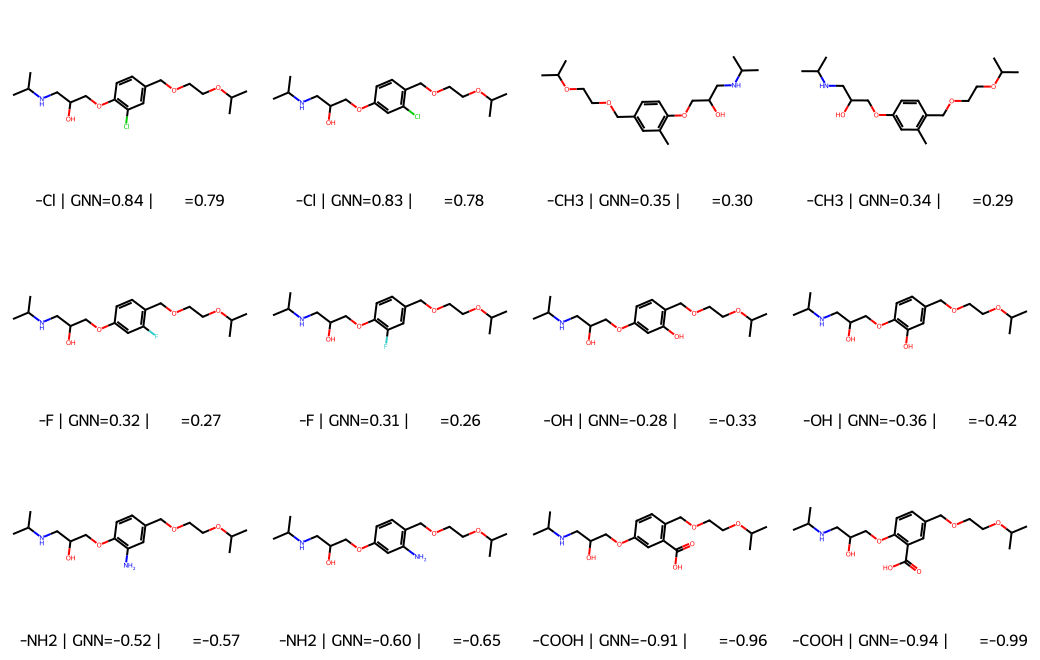

In [ ]:
# ============================================================
# Part 14-6. 구조 최적화 시스템 실행 예시
# ============================================================
# 아래 INPUT_SMILES를 원하는 분자의 SMILES로 바꾸면 됩니다.
# 목표 logD 범위도 연구 목적에 따라 수정할 수 있습니다.

INPUT_SMILES = work_df.loc[scaffold_test_idx[0], SMILES_COL]  # 예시: test set 첫 번째 분자
TARGET_LOGD_MIN = 1.0
TARGET_LOGD_MAX = 3.0

original_pred, recommendation_df = recommend_logd_optimized_structures(
    INPUT_SMILES,
    target_min=TARGET_LOGD_MIN,
    target_max=TARGET_LOGD_MAX,
    top_n=12,
    max_candidates_per_reaction=30
)

print("입력 SMILES:", INPUT_SMILES)
print("\n원본 분자 예측 결과")
print(original_pred)

print("\n추천 후보")
display(recommendation_df)

explain_optimization_result(original_pred, recommendation_df)
visualize_recommendations(recommendation_df)


In [ ]:
# ============================================================
# Part 14-7. 최적화 추천 결과 저장
# ============================================================

if "recommendation_df" in globals() and recommendation_df is not None and not recommendation_df.empty:
    recommendation_df.to_csv("logD_structure_optimization_recommendations.csv", index=False)
    print("저장 완료:")
    print("- logD_structure_optimization_recommendations.csv")
else:
    print("저장할 추천 후보가 없습니다.")


저장 완료:
- logD_structure_optimization_recommendations.csv


# Part 15. 결과 해석 및 보고서 작성용 설명

이 노트북에서 구현한 시스템은 단순히 logD를 예측하는 데서 끝나지 않고, 예측 결과를 이용해 구조 변형 후보를 제안합니다.

- Random Forest는 Morgan Fingerprint를 입력으로 사용하므로 분자의 부분구조 패턴을 빠르게 학습할 수 있습니다.
- GNN은 원자와 결합 정보를 그래프로 직접 학습하므로 fingerprint로 압축되기 전의 구조 정보를 반영할 수 있습니다.
- Scaffold split은 같은 골격의 분자가 train/test에 동시에 들어가는 것을 막기 때문에 실제 신약개발 상황에 더 가까운 평가 방식입니다.
- RF-GNN ensemble은 성능 비교용으로 계산했지만, 최종 구조 추천에는 성능이 가장 우수한 GNN 단독 모델을 사용합니다.
- RF와 GNN의 예측 차이인 model disagreement는 참고용 불확실성 지표로만 사용합니다.
- 구조 최적화 단계에서는 -OH, -NH2, -COOH, -F, -Cl, -CH3 등의 작용기 변형 후보를 만들고, 각 후보의 logD를 GNN 단독 모델로 다시 예측하여 목표 범위(예: 1–3)에 들어오는 후보를 추천합니다. 범위 안에서는 중심값에 가까운 정도를 추가 점수화하지 않습니다.

최종적으로 이 코드는 연구계획서의 목표인 “SMILES 기반 logD 예측 + 모델 비교 + GNN 단독 최종 예측 + 목표 logD 범위 기반 구조 추천 시스템”을 하나의 pipeline으로 구현한 것입니다.
